In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import lightgbm as lgb
import warnings 
warnings.filterwarnings('ignore')

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = ["Malgun Gothic", "DejaVu Sans"]

In [6]:
train = pd.read_csv("../data/train_fe.csv")
test = pd.read_csv("../data/test_fe.csv")

target = "addicted_label"
cat_raw_cols = ["gender", "stress_level", "academic_work_impact"]
drop_cols = ["id", target] + cat_raw_cols
features = [c for c in train.columns if c not in drop_cols]

X = train[features]
y = train[target]

#### 해석용 모델 학습

CV 대신 전체 데이터로 한 번 더 학습 
(SHAP은 일반화 검증용이 아님. 모델이 뭘 학습했는지 보는 용도)

In [7]:
lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.03,
    "num_leaves": 63,
    "seed": 42,
    "verbosity": -1,
}

full_train_set = lgb.Dataset(X, y)
final_model = lgb.train(lgb_params, full_train_set, num_boost_round=500)

X_sample = X.sample(n=20000, random_state=42)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)

#### SHAP Summary Plot

방향(빨강=값 큼)까지 확인. gain importance 순위와 방향이 맞는지 체크

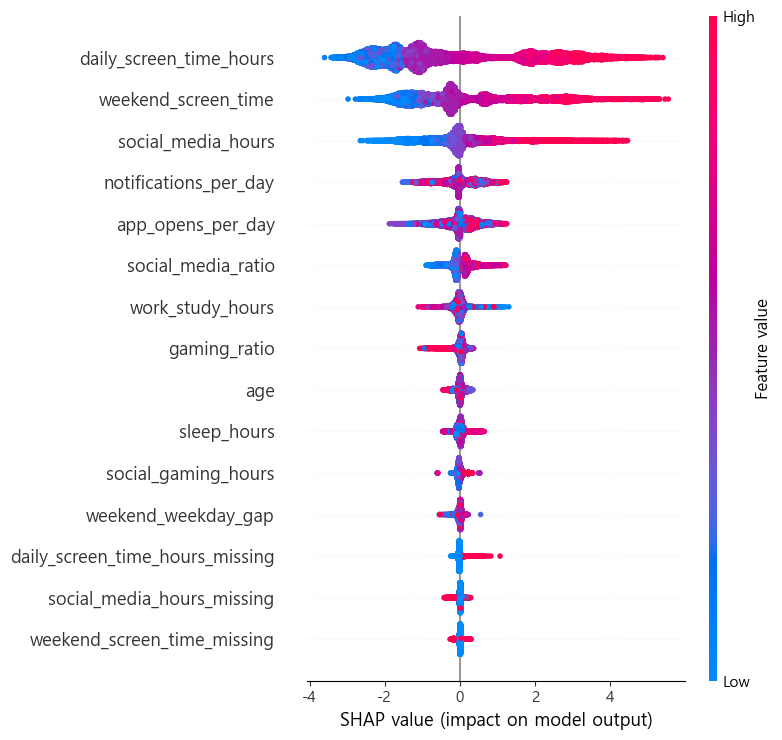

In [8]:
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.tight_layout()
plt.show()

#### notifications_per_day dependence plot

- 단독 상관은 0에 가까운데 gain importance는 4위. 
- 조건부로만 작동하는지 확인

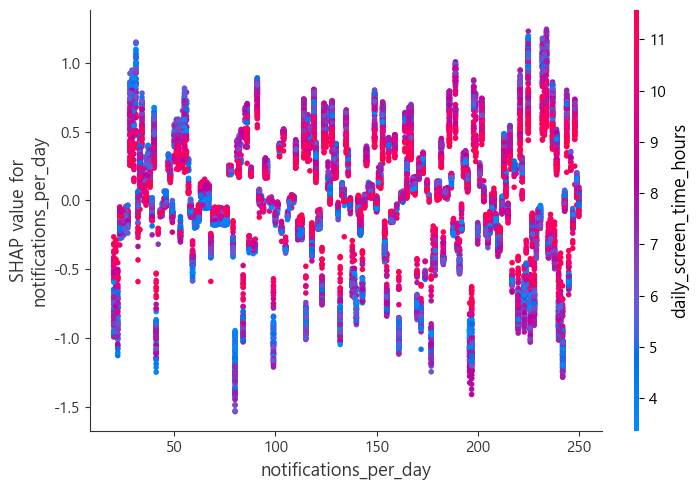

In [9]:
shap.dependence_plot("notifications_per_day", shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

#### gaming_ratio dependence plot

- 상관계수 -0.19 확인용. 
- 값 커질수록 SHAP 값 방향이 실제로 반대인지 확인

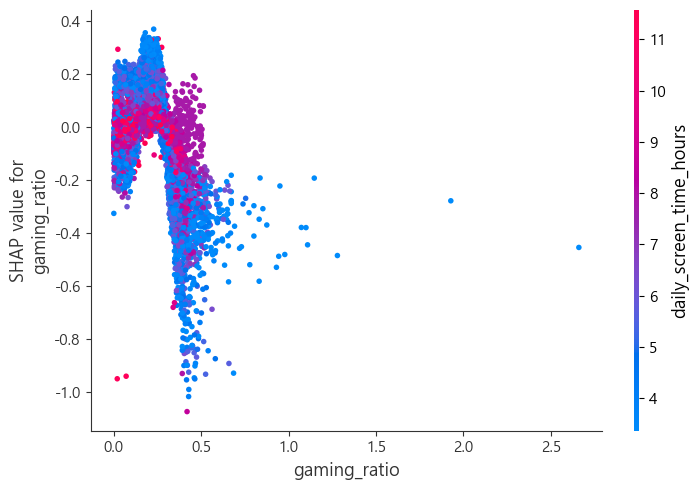

In [10]:
shap.dependence_plot("gaming_ratio", shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

#### daily_screen_time_hours dependence plot

- 압도적 1위 변수. 
- 특정 구간에서 꺾이는 지점이 있는지 확인

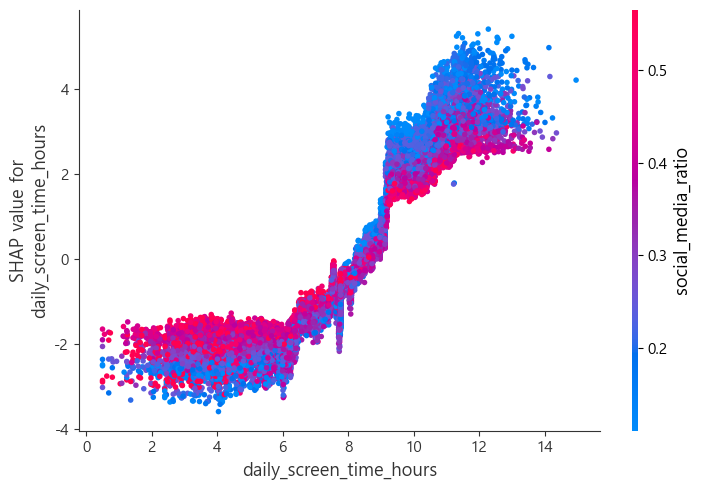

In [11]:
shap.dependence_plot("daily_screen_time_hours", shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

#### Waterfall plot (개별 사용자 1명)

전역 평균이 아니라 특정 사용자 하나가 왜 이 확률로 예측됐는지 확인

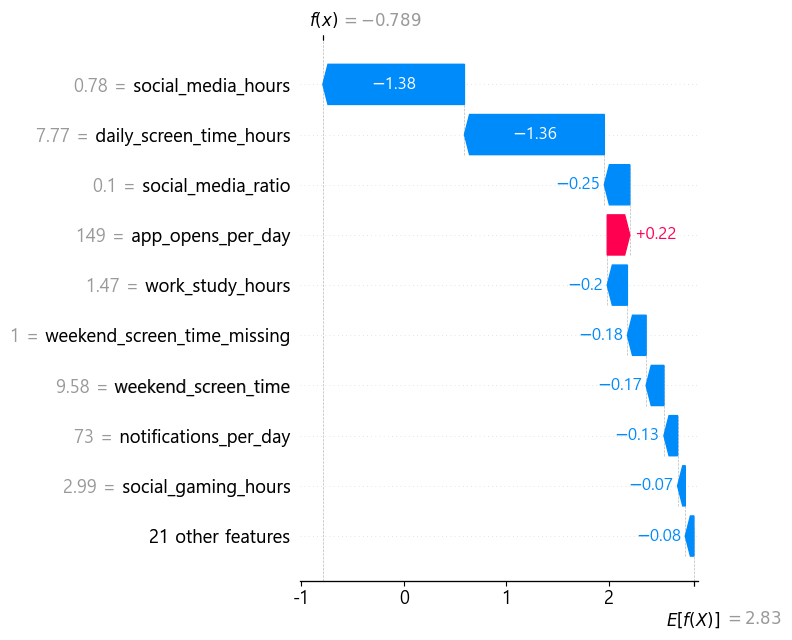

In [15]:
idx = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[idx],
        feature_names=features,
    ),
    show=False,
)
plt.tight_layout()
plt.show()